In [ ]:
## =============================================================================
## Fig.2B:
##
## Mantel_virus_bacteria.R
## -----------------------------------------------------------------------------
## 
##   Test whether the DNA viral community composition co-varies with the BACTERIAL
##   community composition, using the MANTEL TEST. The Mantel test correlates two
##   distance matrices, so it uses the FULL bacterial community (no dimensionality
##   reduction, no single-value summary, no PCoA axis).
##
##   Run SEPARATELY for:
##     (a) bacterial ABUNDANCE community (DNA metagenome)
##     (b) bacterial ACTIVITY  community (RNA metatranscriptome)
##
## OUTPUTS
##   Table_mantel_results.csv : r statistic, p, permutations, n, method
##   Fig_mantel_abundance.pdf : viral vs bacterial-abundance distance scatter
##   Fig_mantel_activity.pdf  : viral vs bacterial-activity  distance scatter
## ===

In [15]:
library(vegan)
library(ggplot2)

In [16]:
setwd("path/")

In [17]:
## ---------------------------- CONFIG ----------------------------------------
VIRUS_FILE <- "data/DNA_Viruses119.txt"                 # genomes x samples (coverage)
BACT_ABUND <- "data/Bacteria_abundance_metagenome.txt"       # genera x samples (DNA)
BACT_ACTIV <- "data/Abundance_Transcript_bacteria.txt"       # genera x samples (RNA)
OUTDIR     <- "out_mantel"
N_PERM     <- 999                                        # permutations
DIST       <- "bray"                                     # dissimilarity index
## ----------------------------------------------------------------------------

dir.create(OUTDIR, showWarnings = FALSE)

In [18]:
## helper: read a taxa x sample table and return sample x taxa relative

read_rel <- function(path){
  b <- read.table(path, header = TRUE, sep = "\t", check.names = FALSE,
                  quote = "", fill = TRUE)
  ## first column may be "Genus" or an unnamed taxon column
  if ("Genus" %in% colnames(b)) { rownames(b) <- make.unique(as.character(b$Genus)); b$Genus <- NULL }
  else { rownames(b) <- make.unique(as.character(b[[1]])); b[[1]] <- NULL }
  ## keep only sample columns (named Unmanip_/HM_/HMM_/LM_ ; tolerate space or underscore)
  scol <- grep("^(Unmanip|HM|HMM|LM)[ _]", colnames(b), value = TRUE)
  m <- as.matrix(sapply(b[, scol], function(x) as.numeric(as.character(x))))
  rownames(m) <- rownames(b); colnames(m) <- gsub(" ", "_", scol)
  m[is.na(m)] <- 0
  decostand(t(m), "total")          # samples x taxa, relative abundance
}

In [19]:
## load viral matrix (genomes x samples)
dv    <- read.table(VIRUS_FILE, header = TRUE, sep = "\t", row.names = 1, check.names = FALSE)
vrel  <- decostand(t(as.matrix(dv)), "total")           # samples x genomes, relative

## load bacterial communities
bab <- read_rel(BACT_ABUND)                             # abundance community
bac <- read_rel(BACT_ACTIV)                             # activity  community

In [20]:
## Align samples across the three matrices

common <- Reduce(intersect, list(rownames(vrel), rownames(bab), rownames(bac)))
message("Samples shared across all three matrices: ", length(common))
vrel <- vrel[common, ]; bab <- bab[common, ]; bac <- bac[common, ]


Samples shared across all three matrices: 25



In [22]:
## distance matrices
d_virus     <- vegdist(vrel, DIST)
d_bact_ab   <- vegdist(bab,  DIST)
d_bact_ac   <- vegdist(bac,  DIST)

In [23]:
d_virus 

           Unmanip_1  Unmanip_3  Unmanip_4  Unmanip_5  Unmanip_7  Unmanip_8
Unmanip_3 0.15032461                                                       
Unmanip_4 0.12381759 0.17587280                                            
Unmanip_5 0.23024501 0.25935927 0.27230840                                 
Unmanip_7 0.16003574 0.11635046 0.17814838 0.20108715                      
Unmanip_8 0.17330257 0.13290792 0.18426909 0.18093266 0.04230149           
HM_1      0.08288631 0.17394449 0.12912858 0.25435899 0.19691804 0.20897772
HM_2      0.09219952 0.11849151 0.12177994 0.24926397 0.13348026 0.13915717
HM_3      0.10156426 0.12017469 0.13141488 0.28129084 0.17286966 0.18812142
HM_4      0.10835031 0.17673708 0.12671398 0.20812738 0.15202485 0.16136737
HM_5      0.09985058 0.13780871 0.14595398 0.28765053 0.18771079 0.20762902
HM_6      0.10904997 0.20378062 0.14573071 0.19236418 0.19736195 0.20651319
HM_7      0.18203818 0.26088341 0.19998840 0.21478269 0.23929263 0.24550278
HMM_1     0.

In [24]:
## Mantel tests (Spearman rank correlation of the two distance matrices)
set.seed(1)
mant_ab <- mantel(d_virus, d_bact_ab, method = "spearman", permutations = N_PERM)
set.seed(1)
mant_ac <- mantel(d_virus, d_bact_ac, method = "spearman", permutations = N_PERM)


In [25]:
## Results table

res <- data.frame(
  bacterial_proxy = c("Abundance (DNA metagenome)", "Activity (RNA metatranscriptome)"),
  mantel_r        = round(c(mant_ab$statistic, mant_ac$statistic), 4),
  p_value         = c(mant_ab$signif, mant_ac$signif),
  permutations    = N_PERM,
  n_samples       = length(common),
  method          = "Spearman; Bray-Curtis on relative abundance"
)

write.csv(res, file.path(OUTDIR, "Table_mantel_results.csv"), row.names = FALSE)

cat("\n================= MANTEL TEST RESULTS =================\n")
print(res, row.names = FALSE)
cat("\nInterpretation: a positive, significant Mantel r means samples with similar\n",
    "viral communities also have similar bacterial communities -> the bacterial\n",
    "community co-structures the viral community (depth-independent).\n", sep = "")



================= MANTEL TEST RESULTS =================
                  bacterial_proxy mantel_r p_value permutations n_samples
       Abundance (DNA metagenome)   0.3068   0.002          999        25
 Activity (RNA metatranscriptome)   0.3300   0.002          999        25
                                      method
 Spearman; Bray-Curtis on relative abundance
 Spearman; Bray-Curtis on relative abundance

Interpretation: a positive, significant Mantel r means samples with similar
viral communities also have similar bacterial communities -> the bacterial
community co-structures the viral community (depth-independent).


## figures: distance-vs-distance scatter with LOESS + linear fit

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


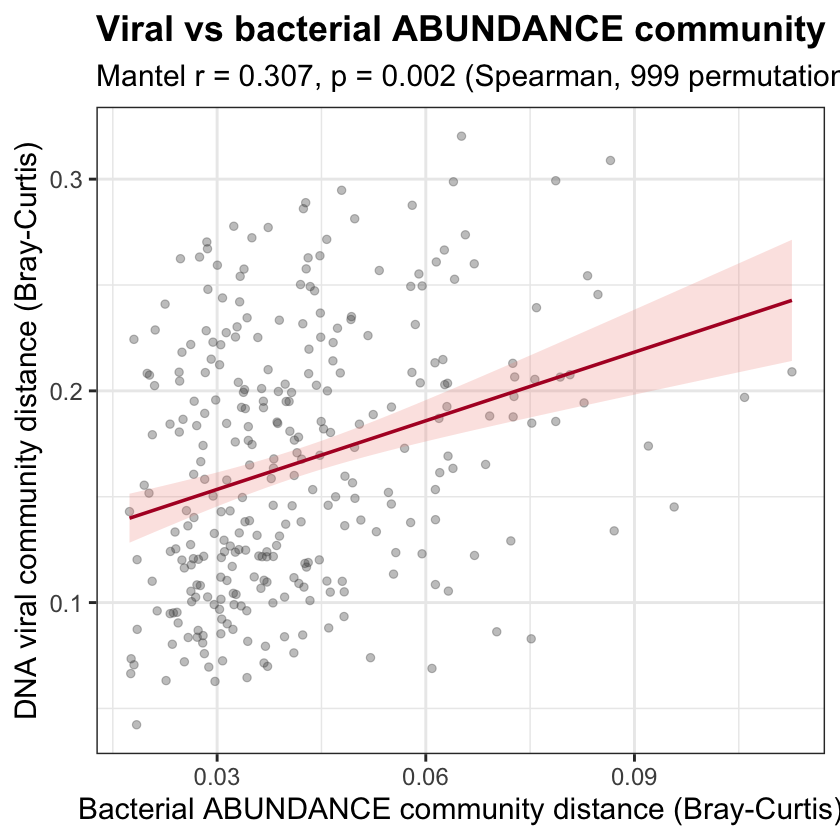


Outputs written to out_mantel/


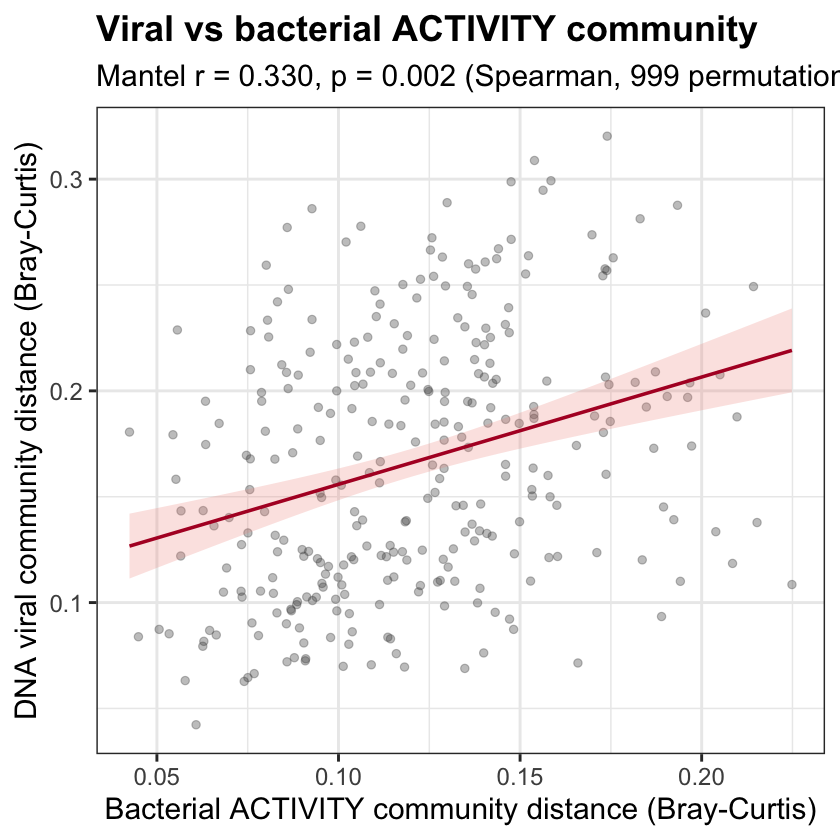

In [28]:

mantel_plot <- function(dx, dy, xlab, ylab, title, r, p, file){
  df <- data.frame(x = as.vector(dx), y = as.vector(dy))
  p1 <- ggplot(df, aes(x, y)) +
    geom_point(alpha = 0.35, size = 2, colour = "grey30") +
    geom_smooth(method = "lm", se = TRUE, colour = "#B2182B", fill = "#F1948A", alpha = .25) +
    labs(x = xlab, y = ylab, title = title,
         subtitle = sprintf("Mantel r = %.3f, p = %.3f (Spearman, %d permutations)", r, p, N_PERM)) +
    theme_bw(base_size = 18) + theme(plot.title = element_text(face = "bold"))
  ggsave(file, p1, width = 4, height = 5.5)
    print(p1)
}
mantel_plot(d_bact_ab, d_virus,
            "Bacterial ABUNDANCE community distance (Bray-Curtis)",
            "DNA viral community distance (Bray-Curtis)",
            "Viral vs bacterial ABUNDANCE community",
            mant_ab$statistic, mant_ab$signif,
            file.path(OUTDIR, "Fig_mantel_abundance.pdf"))
mantel_plot(d_bact_ac, d_virus,
            "Bacterial ACTIVITY community distance (Bray-Curtis)",
            "DNA viral community distance (Bray-Curtis)",
            "Viral vs bacterial ACTIVITY community",
            mant_ac$statistic, mant_ac$signif,
            file.path(OUTDIR, "Fig_mantel_activity.pdf"))

cat("\nOutputs written to ", OUTDIR, "/\n", sep = "")
